In [1]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
plt.style.use('rdn.plotstyles.presentation')
import numpy as np



In [194]:
def input_curr(t):

    if t>150: return 0
    else: return 2


class Gerstner():
    def __init__(self):
        self.p = {
                'C' : 1,
                'gl' : .3, #mS/mm2
                'u_l' : -65., #mV
                'g_k' : 35,
                'u_k' : -77,
                'g_na' : 40,
                'u_na' : 55.,

                'alpha_n' : lambda u: (0.02*(u-25))/(1-np.exp(-(u-25)/9)),
                'alpha_m' : lambda u: (0.182*(u+35))/(1-np.exp(-(u+35)/9)),
                'alpha_h' : lambda u: 0.25*np.exp(-(u+90)/12),

                'beta_n' : lambda u: -0.002*(u-25)/(1-np.exp((u-25)/9)),
                'beta_m' : lambda u: -0.124*(u+35)/(1-np.exp((u+35)/9)),
                'beta_h' : lambda u: 0.25*np.exp((u+62)/6)/np.exp((u+90)/12),
            }

    def gen_dvdt(self):
        def dvdt(t, x):
            p = self.p
            u, n, m, h = x
            dudt = 1./p.get('C') * (
                - p.get('gl')*(u-p.get('u_l')) \
                - p.get('g_k')*(n**4)*(u-p.get('u_k')) \
                - p.get('g_na')*(m**3)*h*(u-p.get('u_na'))
                + input_curr(t)
            )

            dndt = p.get('alpha_n')(u)*(1-n) - p.get('beta_n')(u)*n
            dmdt = p.get('alpha_m')(u)*(1-m) - p.get('beta_m')(u)*m
            dhdt = p.get('alpha_h')(u)*(1-h) - p.get('beta_h')(u)*h

            return dudt, dndt, dmdt, dhdt

        return dvdt

class Guy():
    def __init__(self):
        self.p = {
                'C' : 1,
                'gl' : .3, #mS/mm2
                'u_l' : 10.6, #mV
                'g_k' : 36.,
                'u_k' : -12.,
                'g_na' : 120,
                'u_na' : 115.,

                'alpha_n' : lambda V: (0.1-0.01*(V+65)) / (np.exp(1-0.1*(V+65)) -1),
                'alpha_m' : lambda V: (2.5-0.1*(V+65)) / (np.exp(2.5-0.1*(V+65)) -1),
                'alpha_h' : lambda V: 0.07*np.exp(-(V+65)/20),

                'beta_n' : lambda V: 0.125*np.exp(-(V+65)/80),
                'beta_m' : lambda V: 4*np.exp(-(V+65)/18),
                'beta_h' : lambda V: 1/(np.exp(3.0-0.1*(V+65))+1),
            }

    def gen_dvdt(self):
        def dvdt(t, x):
            p = self.p
            u, n, m, h = x
            dudt = 1./p.get('C') * (
                - p.get('gl')*(u-p.get('u_l')+65) \
                - p.get('g_k')*(n**4)*(u-p.get('u_k')+65) \
                - p.get('g_na')*(m**3)*h*(u-p.get('u_na')+65)
                + input_curr(t)
            )

            dndt = p.get('alpha_n')(u)*(1-n) - p.get('beta_n')(u)*n
            dmdt = p.get('alpha_m')(u)*(1-m) - p.get('beta_m')(u)*m
            dhdt = p.get('alpha_h')(u)*(1-h) - p.get('beta_h')(u)*h

            return dudt, dndt, dmdt, dhdt

        return dvdt

gerstner = Gerstner()
y0 = [-75,0,0.05,0.55]



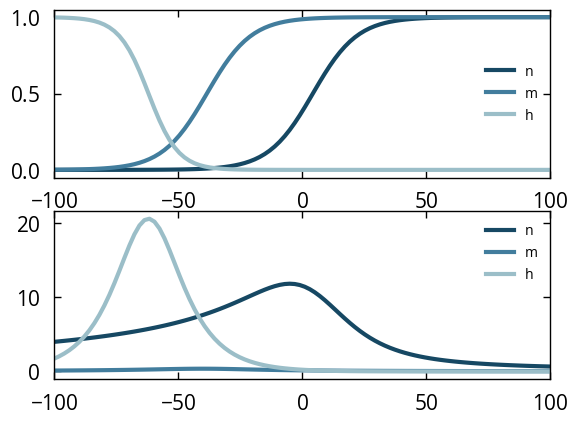

In [195]:
x_u = np.linspace(-100,100,100)


def n_inf(u, alpha, beta):
    return alpha(u)/(alpha(u)+beta(u))

def tau_inf(u, alpha, beta):
    return 1/(alpha(u)+beta(u))

fig, axs = plt.subplots(2,1)
axs[0].plot(x_u, n_inf(x_u, gerstner.p.get('alpha_n'),gerstner.p.get('beta_n')), label='n')
axs[0].plot(x_u, n_inf(x_u, gerstner.p.get('alpha_m'),gerstner.p.get('beta_m')), label='m')
axs[0].plot(x_u, n_inf(x_u, gerstner.p.get('alpha_h'),gerstner.p.get('beta_h')), label='h')
axs[0].legend()

axs[1].plot(x_u, tau_inf(x_u, gerstner.p.get('alpha_n'),gerstner.p.get('beta_n')), label='n')
axs[1].plot(x_u, tau_inf(x_u, gerstner.p.get('alpha_m'),gerstner.p.get('beta_m')), label='m')
axs[1].plot(x_u, tau_inf(x_u, gerstner.p.get('alpha_h'),gerstner.p.get('beta_h')), label='h')
axs[1].legend()

In [196]:
sol = solve_ivp(gerstner.gen_dvdt(), [0,300], y0, method='RK45')

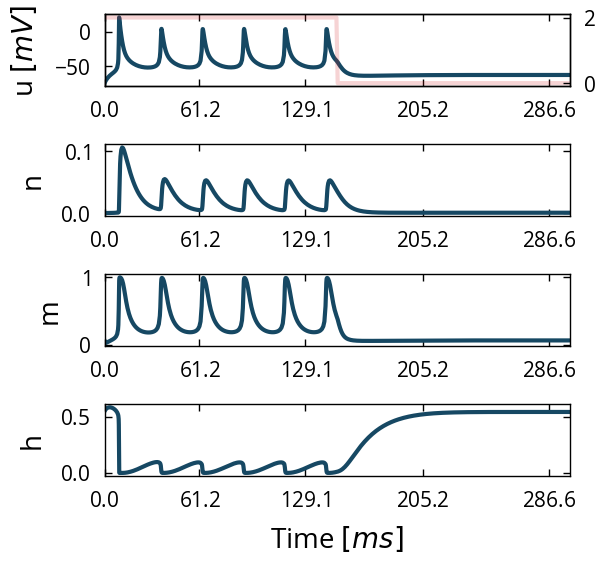

In [197]:
fig, axs = plt.subplots(4,1, figsize=(6,6))
fig.subplots_adjust(hspace=0.8)

y_labels = [r'u $[mV]$', 'n', 'm', 'h']

for y, ax, ylab in zip(sol.y, axs, y_labels):
    ax.plot(sol.t, y, zorder=1)
    ax.set_ylabel(ylab)

    ax.set_xticks(sol.t[::100])

currs = [input_curr(t) for t in sol.t]
axs[0].twinx().plot(sol.t, currs, c='tab:red', zorder=0, alpha=0.2)

ax.set_xlabel(r'Time $[ms]$');
